# Аггрегация данных #

Пришло время собрать всю информацию воендино и провесети анализ

In [3]:
! git clone https://github.com/mnedo/SMADIMO_GP2/

Cloning into 'SMADIMO_GP2'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 28 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 212.06 KiB | 3.37 MiB/s, done.
Resolving deltas: 100% (9/9), done.


## Загрзка собранных раннее данных ##

In [5]:
import pandas as pd

In [6]:
cities = pd.read_excel('/content/SMADIMO_GP2/Data/cities.xlsx')
cities.head(3)

,Unnamed: 0,Город,Регион,Федеральный округ,Население,Наличие аэропорта
0,1,Абакан,Хакасия,Сибирский,184284,True
1,26,Анадырь,Чукотский АО,Дальневосточный,13224,True
2,27,Анапа,Краснодарский край,Южный,84804,True


In [103]:
flights = pd.read_excel('/content/SMADIMO_GP2/Data/flights.xlsx')
flights.head(3)

,from_city,from_code,to_city,to_code,price,duration
0,Абакан,ABA,Анадырь,DYR,39655,2850
1,Абакан,ABA,Барнаул,BAX,11714,175
2,Абакан,ABA,Владивосток,VVO,20241,2015


In [7]:
hotels = pd.read_excel('/content/SMADIMO_GP2/Data/hotels.xlsx')
hotels.head(3)

,city_name,hotel_name,reviews_count,rating_value,price_per_night,latitude,longitude
0,Абакан,Гостиница Хакасия,98.0,8.2,5540,53.722572,91.44298
1,Абакан,AZIMUT Отель Абакан 3*,16.0,9.3,4828,53.721160,91.43992
2,Абакан,Уютная Квартира в Центре Города,19.0,9.7,2666,53.719868,91.42204


In [9]:
sightseens = pd.read_csv('/content/SMADIMO_GP2/Data/sightseens.csv')
sightseens.head(3)

,city,rubric,name,lat,lon,rating,review_count
0,Абакан,Рестораны,"STIX, бельгийский ресторан",53.721736,91.444138,4.7,648
1,Абакан,Рестораны,"Мажор, караоке-бар",53.725752,91.456086,4.7,307
2,Абакан,Рестораны,"Мадрид, кафе",53.727392,91.437827,4.6,300


## Стоимость путшествия ##

## Привлекательность местоположение

Для каждого города и типа достопримечательности у нас есть разное количество оценок. И конечно количество оценок должно иметь вес при учете средней оценки - рейтинга.

Введем коэффициент важности оценки: Доля от максимального количество оценок в city+rubric

In [50]:
gr = sightseens.groupby(by=['city', 'rubric']).agg({'review_count': 'max'}).rename(columns={'review_count': 'max_count'}).reset_index()
sightseens = sightseens.merge(gr, on=['city', 'rubric'])

In [56]:
sightseens['review_importance'] = sightseens['review_count']/sightseens['max_count']
sightseens['I'] = sightseens['rating']*sightseens['review_importance'] # total importance
rng, Imin = sightseens['I'].max() - sightseens['I'].min(), sightseens['I'].min()
sightseens['I'] = (sightseens['I']-Imin)/rng

In [52]:
import matplotlib.pyplot as plt

In [53]:
help(plt.hist)

Help on function hist in module matplotlib.pyplot:

hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, *, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distribution ei

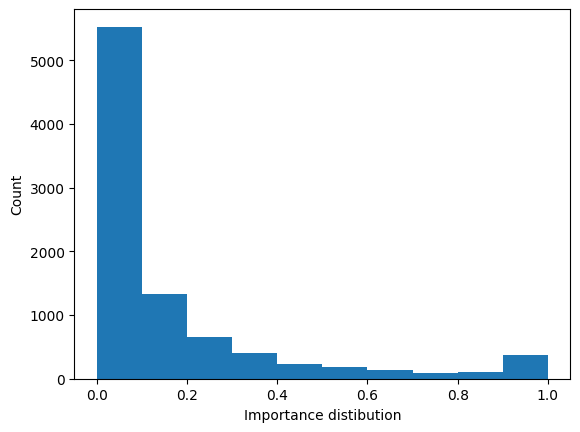

In [58]:
plt.hist(sightseens['I'], range=(0, 1))
plt.xlabel('Importance distibution')
plt.ylabel('Count')
plt.show()

In [77]:
calcdf = hotels[['city_name', 'hotel_name', 'latitude',	'longitude']].rename(columns={'city_name': 'city'}).merge(sightseens[['city', 'I', 'lat', 'lon', 'rubric']], on='city')
calcdf.head(3)

,city,hotel_name,latitude,longitude,I,lat,lon,rubric
0,Абакан,Гостиница Хакасия,53.722572,91.44298,0.560884,53.721736,91.444138,Рестораны
1,Абакан,Гостиница Хакасия,53.722572,91.44298,0.265727,53.725752,91.456086,Рестораны
2,Абакан,Гостиница Хакасия,53.722572,91.44298,0.254144,53.727392,91.437827,Рестораны


Мы будем использовать библиотеку geopy как доп. инструмент для расчета расстояния по широте и долготое: https://pypi.org/project/geopy/

In [78]:
pip install geopy

In [79]:
from geopy.distance import geodesic as dist

In [80]:
calcdf = calcdf.dropna()

In [81]:
calcdf['slagaemoe'] = calcdf.apply(lambda row: dist((row['latitude'], row['longitude']), (row['lat'], row['lon'])).km * row['I'], axis=1)
calcdf.head(3)

,city,hotel_name,latitude,longitude,I,lat,lon,rubric,slagaemoe
0,Абакан,Гостиница Хакасия,53.722572,91.44298,0.560884,53.721736,91.444138,Рестораны,0.067542
1,Абакан,Гостиница Хакасия,53.722572,91.44298,0.265727,53.725752,91.456086,Рестораны,0.248378
2,Абакан,Гостиница Хакасия,53.722572,91.44298,0.254144,53.727392,91.437827,Рестораны,0.161434


In [85]:
gr = calcdf.groupby(by=['hotel_name', 'rubric']).agg({'slagaemoe': 'sum'}).rename(columns={'slagaemoe': 'weigthed_sum_atnes'}).reset_index()
rng, Imin = gr['weigthed_sum_atnes'].max() - gr['weigthed_sum_atnes'].min(), gr['weigthed_sum_atnes'].min()
gr['weigthed_sum_atnes'] = (gr['weigthed_sum_atnes']-Imin)/rng

## Обогощение отелей ##

In [87]:
pvt = gr.pivot_table(index='hotel_name', columns='rubric', values='weigthed_sum_atnes').reset_index()
hotels_w = hotels[['city_name',	'hotel_name',	'reviews_count',	'rating_value',	'price_per_night']].merge(pvt, on='hotel_name', how='left')
hotels_w.head(3)

,city_name,hotel_name,reviews_count,rating_value,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры
0,Абакан,Гостиница Хакасия,98.0,8.2,5540,0.092447,0.070102,0.039993,0.026308,0.056243
1,Абакан,AZIMUT Отель Абакан 3*,16.0,9.3,4828,0.092638,0.070232,0.039991,0.026722,0.056354
2,Абакан,Уютная Квартира в Центре Города,19.0,9.7,2666,0.094128,0.071434,0.040277,0.029049,0.058024


In [88]:
# SAVE
# to-delete

hotels_w.to_excel("hotels_w.xlsx", index=False)
from google.colab import files
hotels_w.download("hotels_w.xlsx")

AttributeError: 'DataFrame' object has no attribute 'download'

In [101]:
# UNSAVE
# to-delete

hotels_w = pd.read_excel('hotels_w.xlsx')

## Анализ и репрезентация полученных результатов ##

Стоит обработать оценку отеля: опять будем учитывать максимальную оценку в городе и отнормируемм

In [ ]:
# !! drop с оценкой или нет

In [102]:
gr = hotels_w.groupby(by=['city_name']).agg({'reviews_count': 'max'}).rename(columns={'reviews_count': 'max_count'}).reset_index()
hotels_w = hotels_w.merge(gr, on=['city_name'])
hotels_w['reviews_importance'] = hotels_w['reviews_count']/hotels_w['max_count']
hotels_w['rating_weighted'] = hotels_w['rating_value']*hotels_w['reviews_importance']
rng, Imin = hotels_w['rating_weighted'].max() - hotels_w['rating_weighted'].min(), hotels_w['rating_weighted'].min()
hotels_w['rating_weighted'] = (hotels_w['rating_weighted']-Imin)/rng
hotels_w.drop(columns=['reviews_importance', 'reviews_count', 'rating_value', 'max_count'], inplace=True)
hotels_w.head(3)

,city_name,hotel_name,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,rating_weighted
0,Абакан,Гостиница Хакасия,5540,0.092447,0.070102,0.039993,0.026308,0.056243,0.352445
1,Абакан,AZIMUT Отель Абакан 3*,4828,0.092638,0.070232,0.039991,0.026722,0.056354,0.065246
2,Абакан,Уютная Квартира в Центре Города,2666,0.094128,0.071434,0.040277,0.029049,0.058024,0.080817


In [ ]:
EDA: распределения по всем достопричеательностям

In [ ]:
EDA: скрипки по всем достопричеательностям

In [ ]:
EDA: корреляции таргета и значений

In [ ]:
Выбор топ-5 городов с лучшими параметрами

In [ ]:
Определение местоположения